# Fine-tuning de modelo para sumarização de diálogos de atendimento ao cliente pelo Twitter

- Realiza fine-tuning do modelo

- Compara performance do modelo "tunado" com a versão padrão

In [ ]:
import os
from typing import List

from datasets import Dataset
import evaluate
from langchain_community.llms import HuggingFacePipeline
import matplotlib.pyplot as plt
from rich import print
from tqdm import tqdm
import numpy as np

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Trainer
)

import torch

In [4]:
# ================================================= #
MODEL_NAME = 'falconsai'
# MODEL_NAME = 't5_small'

RUN_FINE_TUNING = True
N_EPOCHS = 30

LOCAL_FT_MODEL_PATH = f'../models/{MODEL_NAME}_ft'
N_MAX_SAMPLES_EVAL = 2327
# ================================================ #


LLM_MODEL_PARAMS = {
    't5_small': {
        'model_name': 'google-t5/t5-small',
        'auto_model_class': AutoModelForSeq2SeqLM,
        'task_pipeline': 'text-generation'
    },
    'falconsai': {
        'model_name': 'Falconsai/text_summarization',
        'auto_model_class': AutoModelForSeq2SeqLM,
        'task_pipeline': 'text-generation'
    }
}

LLM_MODEL_NAME = LLM_MODEL_PARAMS[MODEL_NAME]['model_name']
TASK_PIPLINE = LLM_MODEL_PARAMS[MODEL_NAME]['task_pipeline']
AUTO_MODEL_CLASS = LLM_MODEL_PARAMS[MODEL_NAME]['auto_model_class']

DEVICE = 'cuda'

PRED_COL_NAME = 'summary_pred'

PATH_PREPARED_DATASET_TRAIN = f'../data/interim/summarization_train.csv'
PATH_PREPARED_DATASET_VALID = f'../data/interim/summarization_valid.csv'
PATH_PREPARED_DATASET_TEST = f'../data/interim/summarization_test.csv'

MODEL_PATH = r'/home/msc/Downloads/hf_models'

In [5]:
df_train = pd.read_csv(PATH_PREPARED_DATASET_TRAIN)
df_valid = pd.read_csv(PATH_PREPARED_DATASET_VALID)
df_test = pd.read_csv(PATH_PREPARED_DATASET_TEST)

print(f'df_train.shape: {df_train.shape}')
print(f'df_valid.shape: {df_valid.shape}')
print(f'df_test.shape: {df_test.shape}')

df_train.head()

df_train.shape: (866, 6)

df_valid.shape: (110, 6)

df_test.shape: (109, 6)

,conversation_id,tweet_ids,created_at_list,tweet_texts,human_summary,elapsed_time
0,b065262210783596c1fe79466b8f8985,"[87068, 87069, 87072, 87076]","{87068: Timestamp('2017-11-30 14:29:00+0000', ...",So neither my iPhone nor my Apple Watch are re...,Health and activity functions are not working ...,1 days 17:43:08
1,1e1d8fd4f95c984fb78687c9e946dc97,"[607293, 607296, 607297, 607297]","{607293: Timestamp('2017-11-22 12:16:27+0000',...",@115850 hi team! i m planning to get Apple Air...,Customer is eager to know about the replacemen...,0 days 00:56:46
2,b5773077fa55c381260390472deff4c2,"[428555, 428556, 739293, 739295]","{428555: Timestamp('2017-10-10 13:33:05+0000',...",@AskAmex Where do I write to address a custome...,Customer having a query about delta card. Agen...,8 days 03:05:49
3,3574d6b4418cb546a90d1561bacd66a2,"[587935, 587938, 587939, 587942, 587942]","{587935: Timestamp('2017-12-03 15:55:31+0000',...","@AmazonHelp @115821 Wow, expected 4 packages y...",The customer have a problem. The agent is very...,0 days 01:02:56
4,f30d2bbc15e7ff32244761b38b67d160,"[861405, 861406]","{861405: Timestamp('2017-10-13 14:20:19+0000',...",@GWRHelp App. I havent been able to purchase a...,Customer cannot purchase a train ticket on the...,0 days 00:18:07


## Fine-tuning

In [ ]:
if RUN_FINE_TUNING:

    local_model_path = f'{MODEL_PATH}/{LLM_MODEL_NAME}'

    tokenizer = AutoTokenizer.from_pretrained(local_model_path)
    model = AUTO_MODEL_CLASS.from_pretrained(
        local_model_path,
        dtype=torch.float32,
        device_map='auto'
    )

    def apply_encoding(examples):
        encodings = tokenizer(
            text=examples['tweet_texts'],
            text_target=examples['human_summary'],
            max_length=1024,
            max_target_length=700,
            truncation=True
        )
        
        encodings['labels'] = [list(label) for label in encodings['labels']]

        return encodings


    df_train_pt = Dataset.from_pandas(df_train, preserve_index=False)

    df_train_pt = df_train_pt.map(
        apply_encoding,
        batched=True,
        remove_columns=df_train_pt.column_names
    )

    df_train_pt.set_format(
        columns=['input_ids', 'attention_mask', 'labels']
    )

    data_collator = DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        model=model,
        padding=True
    )

    training_args = TrainingArguments(
        output_dir=LOCAL_FT_MODEL_PATH,
        num_train_epochs=N_EPOCHS,
        warmup_steps=200,
        weight_decay=0.01,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        max_grad_norm=1.0,
        logging_steps=10,
        eval_steps=100,
        logging_strategy='epoch',
        save_strategy='epoch',
        save_total_limit=2,
        dataloader_num_workers=4
    )

    df_valid_pt = Dataset.from_pandas(df_valid, preserve_index=False)

    trainer = Trainer(
        model=model,
        processing_class=tokenizer,
        args=training_args,
        data_collator=data_collator,
        train_dataset=df_train_pt, 
        eval_dataset=df_valid_pt,
        preprocess_logits_for_metrics=preprocess_logits_for_metrics,
        compute_metrics=compute_metrics
    )

    trainer.train()

    trainer.save_model(LOCAL_FT_MODEL_PATH)
    tokenizer.save_pretrained(LOCAL_FT_MODEL_PATH)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Map:   0%|          | 0/866 [00:00<?, ? examples/s]

{'loss': '29.82', 'grad_norm': '2.047', 'learning_rate': '1.95e-05', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '27.82', 'grad_norm': '9.668', 'learning_rate': '4.05e-05', 'epoch': '2'}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '10.72', 'grad_norm': '1.023', 'learning_rate': '1.364e-06', 'epoch': '30'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '1189', 'train_samples_per_second': '21.86', 'train_steps_per_second': '0.353', 'train_loss': '15.39', 'epoch': '30'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

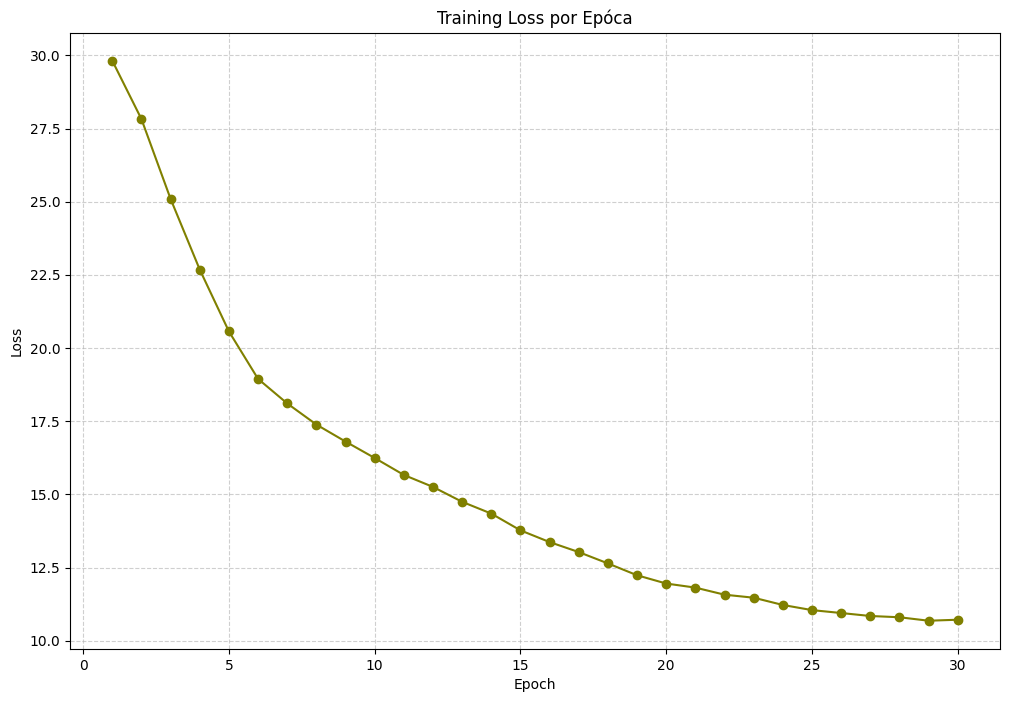

In [7]:
logs = trainer.state.log_history
df_train_hist = pd.DataFrame(logs)
df_loss = df_train_hist[df_train_hist['loss'].notna()]

plt.figure(figsize=(12, 8))
plt.plot(df_loss['epoch'], df_loss['loss'], marker='o', color='olive')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss por Epóca')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(f'../imgs/loss_plot_ft_model_{MODEL_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
if RUN_FINE_TUNING:
    model_ft = trainer.model
else:
    tokenizer = AutoTokenizer.from_pretrained(LOCAL_FT_MODEL_PATH)
    model_ft = AUTO_MODEL_CLASS.from_pretrained(
        LOCAL_FT_MODEL_PATH,
        dtype=torch.float32,
        device_map='auto'
    )

## Avalia performance

In [ ]:
def llm_summarization(input_text: str, model=model_ft, tokenizer=tokenizer) -> str:
    prompt = f'summarize: {input_text}'

    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True
    ).to(model.device)

    outputs = model.generate(
        inputs['input_ids'], 
        max_new_tokens=100,
        do_sample=False,
        
        max_length=700, 
        min_length=40, 
        length_penalty=2.0,
        num_beams=4,
        early_stopping=True
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True).strip()


def run_llm_summarization(
    df: pd.DataFrame,
    llm_tokenizer=tokenizer,
    llm_model: HuggingFacePipeline = None,
) -> List[str]:
    res = []
    for _, df_i in tqdm(df.iterrows(), total=len(df)):
        res_llm = llm_summarization(
            input_text=df_i.tweet_texts
        )
        res.append(res_llm)

    return res

In [10]:
df_eval = df_test.copy()

In [11]:
res_model = run_llm_summarization(
    df=df_eval
)
print(f'🤖 {LLM_MODEL_NAME}:\n\n{res_model[:3]} ...\n')

100%|██████████| 109/109 [00:46<00:00,  2.34it/s]


🤖 Falconsai/text_summarization:

['Customer is complaining that their watchlist is not updating with new episodes. Agent updates that they will 
check the show page for the new eps and also they will support if they happen to need anything else.', 'Customer is
asking to verify their acc where a code / call wil be be sent to his old number. Agent updated that they have 
personal info and updated that they have updated their case manager.', "The customer is complaining that they can't
even use some apps on their phone. The agent asked the customer to DM and they will work from there if they 
can't."] ...

In [12]:
df_eval[PRED_COL_NAME] = res_model

In [13]:
def calc_rouge_metric(
    df: pd.DataFrame,
    target_name: str = 'target',
    pred_name: str = 'pred'
) -> pd.DataFrame:
    rouge_metric = evaluate.load('rouge')

    df_hf = Dataset.from_pandas(df)

    score = rouge_metric.compute(
        predictions=df_hf[target_name],
        references=df_hf[pred_name]
    )

    df_metrics = pd.DataFrame({LLM_MODEL_NAME: score})
    return df_metrics

In [14]:
df_metrics = calc_rouge_metric(
    df=df_eval,
    target_name='human_summary',
    pred_name=PRED_COL_NAME
)
df_metrics = df_metrics.T.reset_index().rename(columns={'index': 'model'})
df_metrics

,model,rouge1,rouge2,rougeL,rougeLsum
0,Falconsai/text_summarization,0.407386,0.180734,0.337834,0.337445


In [15]:
df_metrics_prev = pd.read_csv(f'../data/processed/df_metrics_{MODEL_NAME}.csv')
df_metrics_prev

,model,rouge1,rouge2,rougeL,rougeLsum
0,Falconsai/text_summarization,0.263383,0.10831,0.215001,0.213951


## Exporta resultados

In [16]:
model_name_output = LLM_MODEL_NAME.split('/')[0].lower().replace('-', '_')
output_path = f'../data/processed/df_eval_ft_{model_name_output}_{N_EPOCHS}.csv'

df_eval.to_csv(output_path, index=False)

print(f'CSV exportado: {output_path}')

CSV exportado: ../data/processed/df_eval_ft_falconsai_30.csv

In [17]:
model_name_output = LLM_MODEL_NAME.split('/')[0].lower().replace('-', '_')
output_path = f'../data/processed/df_metrics_ft_{model_name_output}_{N_EPOCHS}.csv'

df_metrics.to_csv(output_path, index=False)

print(f'CSV exportado: {output_path}')

CSV exportado: ../data/processed/df_metrics_ft_falconsai_30.csv